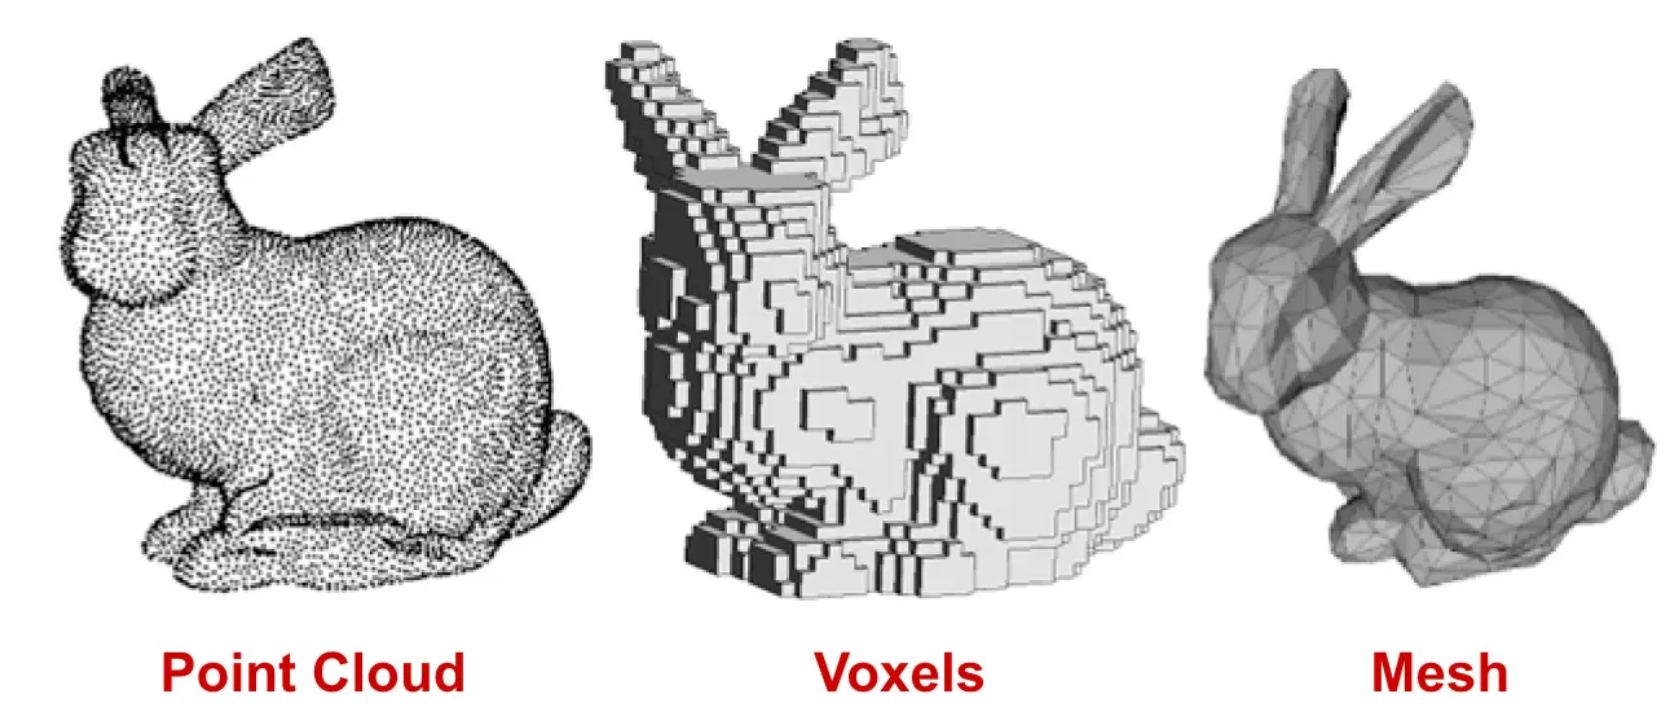

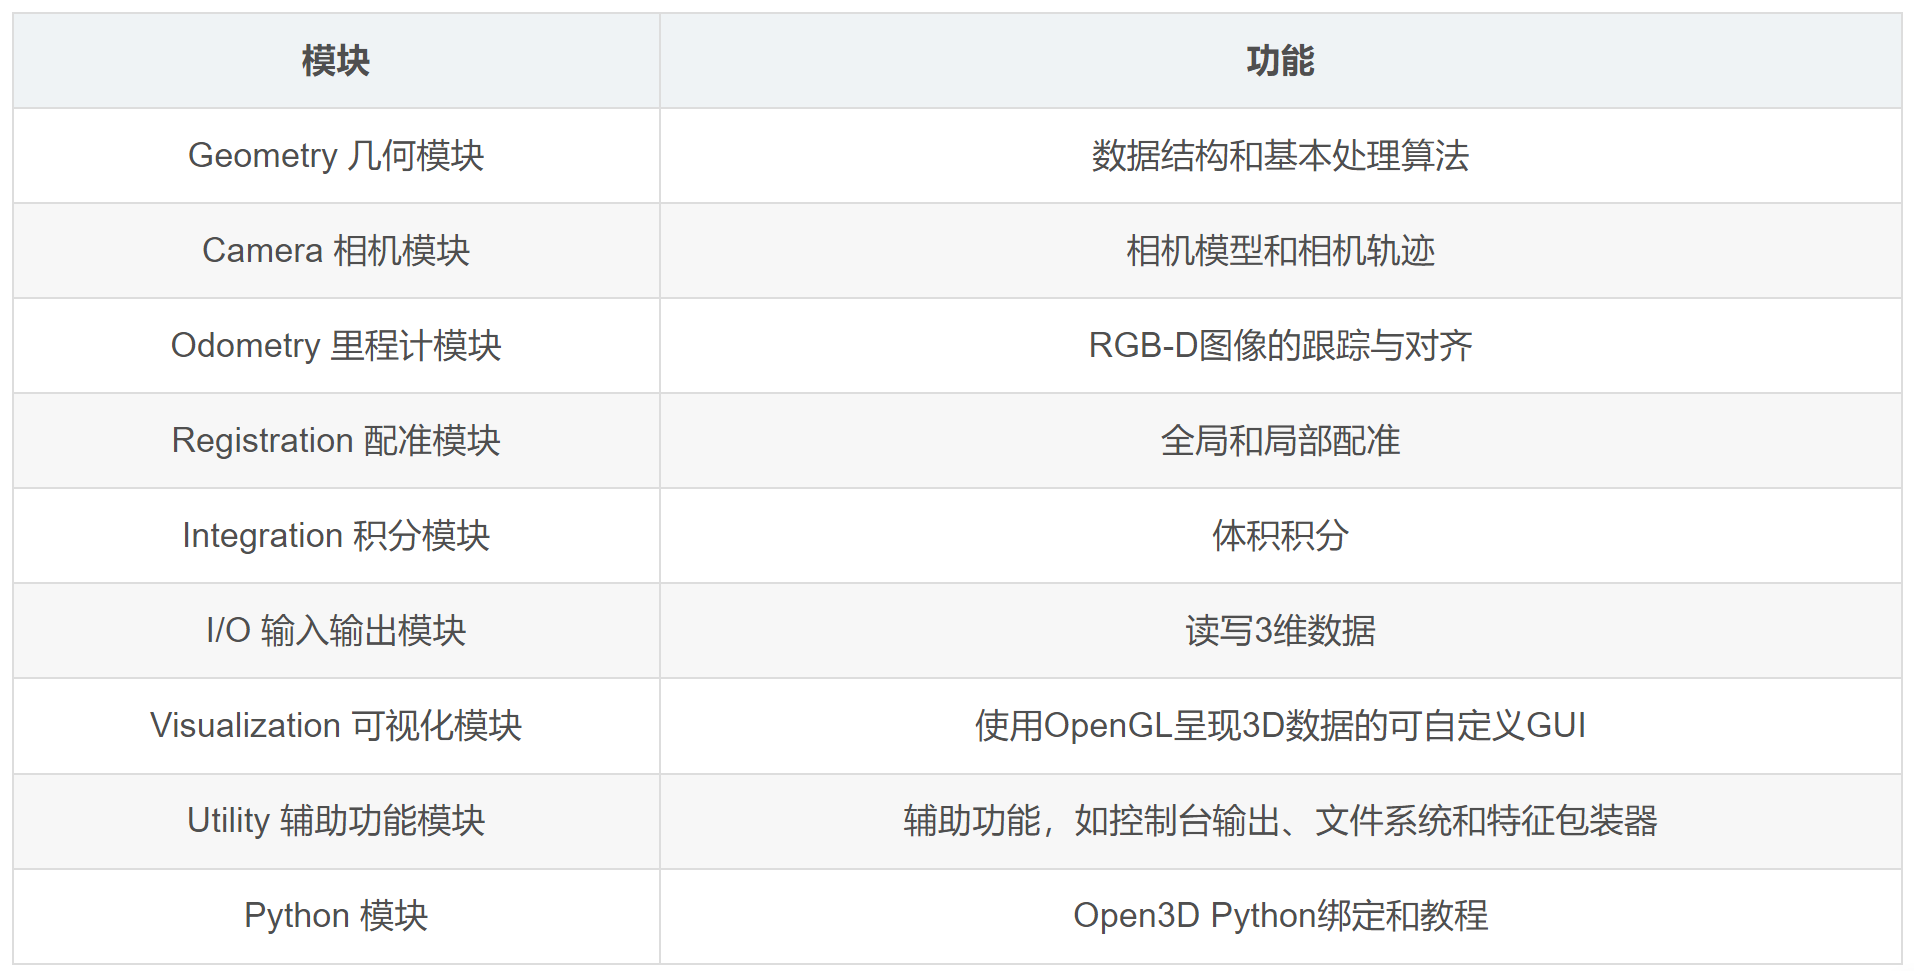

支援三種格式: Point Cloud、Mesh、RGB-D


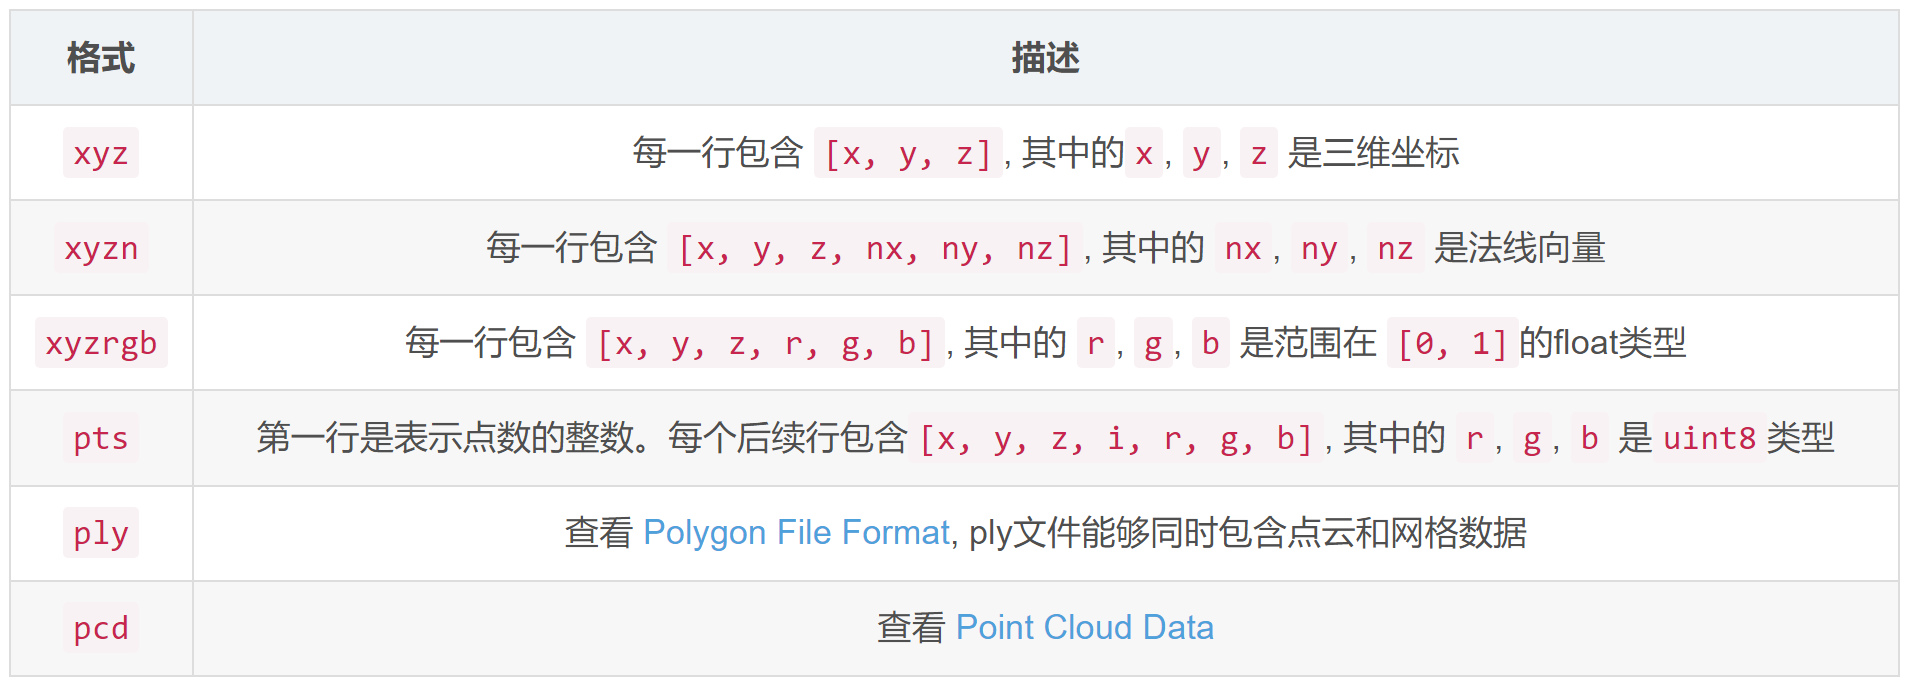

In [1]:
import open3d as o3d
import numpy as np
print("Load a ply point cloud, print it, and render it")
ply_point_cloud = o3d.data.PLYPointCloud()
print(ply_point_cloud.path)
pcd = o3d.io.read_point_cloud(ply_point_cloud.path)

def custom_draw_geometry(pcd):
    # The following code achieves the same effect as:
    # o3d.visualization.draw_geometries([pcd])
    vis = o3d.visualization.Visualizer()
    vis.create_window() #vis.create_window(window_name="Open3D", width=1920, height=1080, left=50, top=50, visible=True)
    vis.add_geometry(pcd)
    vis.run()
    vis.destroy_window()

        
#read_point_cloud reads a point cloud from a file. It tries to decode the file based on the extension name. For a list of supported file types, refer to File IO.
print(pcd)
print(np.asarray(pcd.points))
'''
o3d.visualization.draw_geometries([pcd],
                                  zoom=0.3412,
                                  front=[0.4257, -0.2125, -0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024])
o3d.visualization.Visualizer().destroy_window()
'''
custom_draw_geometry(pcd)


#draw_geometries visualizes the point cloud. Use a mouse/trackpad to see the geometry from different view points.
#It looks like a dense surface, but it is actually a point cloud rendered as surfels. The GUI supports various keyboard functions. For instance, the - key reduces the size of the points (surfels).


Load a ply point cloud, print it, and render it
/Users/hjc/open3d_data/extract/PLYPointCloud/fragment.ply
PointCloud with 196133 points.
[[0.65234375 0.84686458 2.37890625]
 [0.65234375 0.83984375 2.38430572]
 [0.66737998 0.83984375 2.37890625]
 ...
 [2.00839925 2.39453125 1.88671875]
 [2.00390625 2.39488506 1.88671875]
 [2.00390625 2.39453125 1.88793314]]


vis.create_window()參數 

| 參數名稱 | 型別 | 預設值 | 說明 |
|-----------|-------|--------|------|
| window_name | str | "Open3D" | 視窗名稱（標題列會顯示）。 |
| width | int | 1920 | 視窗寬度（像素）。 |
| height | int | 1080 | 視窗高度（像素）。 |
| left | int | 50 | 視窗在螢幕 X 座標（左上角位置）。 |
| top | int | 50 | 視窗在螢幕 Y 座標（左上角位置）。 |
| visible | bool | True | 是否在建立時就立即顯示視窗。 |

o3d.visualization.Visualizer() （Visualizer 的常用方法）

| 方法 | 說明 |
|------|------|
| create_window() | 建立視窗（真正的視窗參數設定在這裡） |
| add_geometry(geometry) | 顯示點雲、網格、LineSet…等幾何物件 |
| remove_geometry(geometry) | 移除已顯示物件 |
| update_geometry(geometry) | 更新視覺化物件（變色、移動等） |
| get_view_control() | 取得攝影機控制器（縮放、旋轉、視角設定） |
| get_render_option() | 取得渲染設定（背景、點大小、顏色等） |
| update_renderer() | 刷新畫面 |
| run() | 啟動交互視窗事件迴圈 |
| destroy_window() | 關閉視窗 |


In [3]:
print("Define parameters used for hidden_point_removal")
camera = [0, 0, diameter]
radius = diameter * 100

print("Get all points that are visible from given view point")
_, pt_map = pcd.hidden_point_removal(camera, radius)

print("Visualize result")
pcd = pcd.select_by_index(pt_map)
o3d.visualization.draw_geometries([pcd])

Define parameters used for hidden_point_removal


NameError: name 'diameter' is not defined

In [4]:
import open3d as o3d
import numpy as np

pcd = o3d.io.read_point_cloud('bunnyData.pts')
alpha  = 0.01
mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(pcd, alpha)
mesh.compute_vertex_normals()
o3d.visualization.draw_geometries([mesh],mesh_show_back_face=True)

In [5]:
import open3d as o3d
import numpy as np
print("Testing mesh in Open3D...")
#armadillo_mesh = o3d.data.ArmadilloMesh()
#mesh = o3d.io.read_triangle_mesh(armadillo_mesh.path)

knot_mesh = o3d.data.KnotMesh()
mesh = o3d.io.read_triangle_mesh(knot_mesh.path)
print(mesh)
print('Vertices:')
print(np.asarray(mesh.vertices))
print('Triangles:')
print(np.asarray(mesh.triangles))

'''
Open3D has a data structure for 3D triangle meshes called TriangleMesh. 
The code below shows how to read a triangle mesh from a ply file and print its vertices and triangles.
The TriangleMesh class has a few data fields such as vertices and triangles. 
Open3D provides direct memory access to these fields via numpy.
'''

Testing mesh in Open3D...
[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220201-data/KnotMesh.ply
[Open3D INFO] Downloaded to /Users/hjc/open3d_data/download/KnotMesh/KnotMesh.ply
TriangleMesh with 1440 points and 2880 triangles.
Vertices:
[[  4.51268387  28.68865967 -76.55680847]
 [  7.63622284  35.52046967 -69.78063965]
 [  6.21986008  44.22465134 -64.82303619]
 ...
 [-22.12651634  31.28466606 -87.37570953]
 [-13.91188431  25.4865818  -86.25827026]
 [ -5.27768707  23.36245346 -81.43279266]]
Triangles:
[[   0   12   13]
 [   0   13    1]
 [   1   13   14]
 ...
 [1438   11 1439]
 [1439   11    0]
 [1439    0 1428]]


'\nOpen3D has a data structure for 3D triangle meshes called TriangleMesh. \nThe code below shows how to read a triangle mesh from a ply file and print its vertices and triangles.\nThe TriangleMesh class has a few data fields such as vertices and triangles. \nOpen3D provides direct memory access to these fields via numpy.\n'

In [6]:
print("Try to render a mesh with normals (exist: " +
      str(mesh.has_vertex_normals()) + ") and colors (exist: " +
      str(mesh.has_vertex_colors()) + ")")
o3d.visualization.draw_geometries([mesh])
print("A mesh with no normals and no colors does not look good.")

'''
You can rotate and move the mesh but it is painted with uniform gray color and does not look 3d. 
The reason is that the current mesh does not have normals for vertices or faces. 
So uniform color shading is used instead of a more sophisticated Phong shading.
'''

Try to render a mesh with normals (exist: False) and colors (exist: False)
A mesh with no normals and no colors does not look good.


'\nYou can rotate and move the mesh but it is painted with uniform gray color and does not look 3d. \nThe reason is that the current mesh does not have normals for vertices or faces. \nSo uniform color shading is used instead of a more sophisticated Phong shading.\n'

In [7]:
print("Computing normal and rendering it.")
mesh.compute_vertex_normals()
print(np.asarray(mesh.triangle_normals))
o3d.visualization.draw_geometries([mesh])
'''
It uses compute_vertex_normals and paint_uniform_color which are member functions of mesh.
'''

Computing normal and rendering it.
[[ 0.79164373 -0.53951444  0.28674793]
 [ 0.8319824  -0.53303008  0.15389681]
 [ 0.83488162 -0.09250101  0.54260136]
 ...
 [ 0.16269924 -0.76215917 -0.6266118 ]
 [ 0.52755226 -0.83707495 -0.14489352]
 [ 0.56778973 -0.76467734 -0.30476777]]


'\nIt uses compute_vertex_normals and paint_uniform_color which are member functions of mesh.\n'

In [8]:
import copy
print("We make a partial mesh of only the first half triangles.")
mesh1 = copy.deepcopy(mesh)
mesh1.triangles = o3d.utility.Vector3iVector(
    np.asarray(mesh1.triangles)[:len(mesh1.triangles) // 2, :])
mesh1.triangle_normals = o3d.utility.Vector3dVector(
    np.asarray(mesh1.triangle_normals)[:len(mesh1.triangle_normals) // 2, :])
print(mesh1.triangles)
o3d.visualization.draw_geometries([mesh1])

'''
We remove half of the surface by directly operating on the triangle and triangle_normals data fields of the mesh. This is done via numpy.
'''

We make a partial mesh of only the first half triangles.
std::vector<Eigen::Vector3i> with 1440 elements.
Use numpy.asarray() to access data.


'\nWe remove half of the surface by directly operating on the triangle and triangle_normals data fields of the mesh. This is done via numpy.\n'

In [ ]:
print("Painting the mesh")
mesh1.paint_uniform_color([1, 0.706, 0])
o3d.visualization.draw_geometries([mesh1])
'''
paint_uniform_color paints the mesh with a uniform color. The color is in RGB space, [0, 1] range.
'''

In [ ]:
import open3d as o3d
import numpy as np
ply_point_cloud = o3d.data.PLYPointCloud()
print("->read point cloud... ")
pcd = o3d.io.read_point_cloud(ply_point_cloud.path)
print(pcd)

print("->write point cloud...")
o3d.io.write_point_cloud("write.pcd", pcd, write_ascii=True)	#default is false，save as Binary；True save as ASICC format (text)
print(pcd)


open3d.io.write_point_cloud()參數

| 參數名稱 | 型別 | 是否必填 | 預設值 | 說明 |
|-----------|-------|-----------|---------|------|
| filename | str | ✅ 是 | 無 | 要輸出的檔案路徑與名稱，例如 `"output.ply"`、`"result.pcd"` |
| pointcloud | open3d.geometry.PointCloud | ✅ 是 | 無 | 要輸出的點雲物件 |
| write_ascii | bool | ❌ 否 | False | 是否以 ASCII（純文字）格式寫出；False 時寫成 binary（較小較快） |
| compressed | bool | ❌ 否 | False | 是否啟用壓縮（僅部分格式支援，如 `.ply`） |
| print_progress | bool | ❌ 否 | False | 是否顯示寫檔進度列（大型點雲有用） |

KD Tree
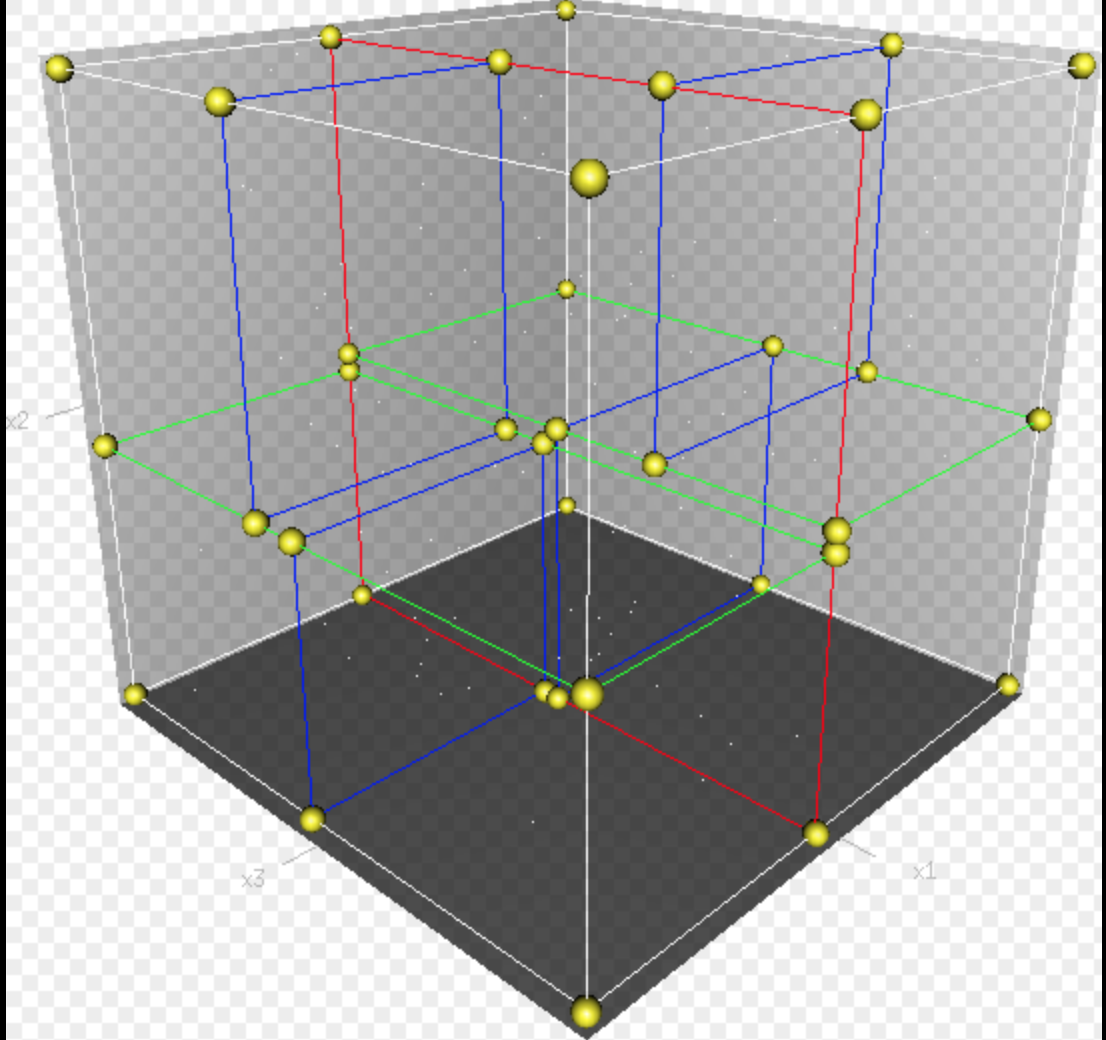
k-d樹（k-維樹的縮寫）是在k維歐幾里德空間組織點的資料結構。k-d樹可以使用在多種應用場合，如多維鍵值搜尋（例：範圍搜尋及最鄰近搜尋）。k-d樹是空間二分樹（binary space partitioning）的一種特殊情況。
k-d樹是每個葉子節點都為k維點的二元樹。所有非葉子節點可以視作用一個超平面把空間分割成兩個半空間。節點左邊的子樹代表在超平面左邊的點，節點右邊的子樹代表在超平面右邊的點。選擇超平面的方法如下：每個節點都與k維中垂直於超平面的那一維有關。因此，如果選擇按照x軸劃分，所有x值小於指定值的節點都會出現在左子樹，所有x值大於指定值的節點都會出現在右子樹。這樣，超平面可以用該x值來確定，其法線為x軸的單位向量。

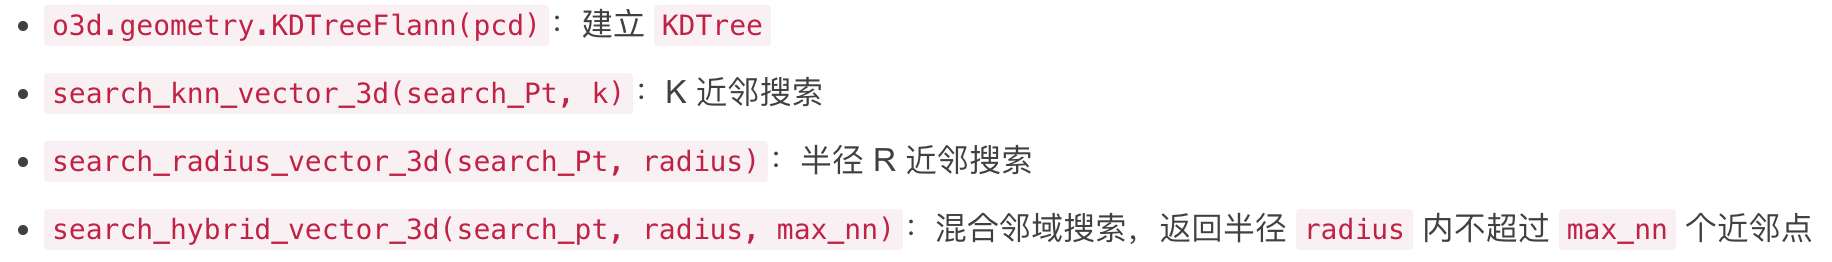
| 函式 / 方法名稱 | 參數 | 回傳 | 說明 |
|----------------|-------|--------|------|
| KDTreeFlann(pointcloud) | pointcloud: PointCloud | KDTreeFlann 物件 | 用點雲初始化 KD 樹 |
| search_knn_vector_3d(query, k) | query: (3,) float list/ndarray<br>k: int | (k, idx, dist) | KNN：搜尋 query 與點雲中距離最近的 k 個點 |
| search_radius_vector_3d(query, radius) | query: (3,) float list/ndarray<br>radius: float | (n, idx, dist) | 在 radius 半徑內搜尋所有鄰居 |
| search_hybrid_vector_3d(query, radius, max_nn) | query: (3,) float nd-array<br>radius: float<br>max_nn: int | (n, idx, dist) | 半徑搜尋 + 限定最大鄰居數（最常用於 ICP / normal estimation） |

In [ ]:
import open3d as o3d
import numpy as np


print("載入點雲中 ")
pcd = o3d.io.read_point_cloud("bunnyData.pts")
print(pcd)

# 將點雲設定為灰色
pcd.paint_uniform_color([0.5, 0.5, 0.5])

# 建立 KDTree
pcd_tree = o3d.geometry.KDTreeFlann(pcd)

# 將第 1500 個點設定為紫色
pcd.colors[1500] = [0.5, 0, 0.5]

# 使用 K 近鄰，將第 1500 個點最近的 5000 個點設定為藍色
print("使用 K 近鄰，將第 1500 個點最近的 5000 個點設定為藍色")
k = 5000    # 設定 K 的大小
[num_k, idx_k, _] = pcd_tree.search_knn_vector_3d(pcd.points[1500], k)    # 返回鄰域點的個數和索引
np.asarray(pcd.colors)[idx_k[1:], :] = [0, 0, 1]  # 跳過最近鄰點（查詢點本身）進行賦色
print("K 鄰域內的點數為：", num_k)

# 使用半徑 R 近鄰，將第 1500 個點半徑（0.02）範圍內的點設定為紅色
print("使用半徑 R 近鄰，將第 1500 個點半徑（0.02）範圍內的點設定為紅色")
radius = 0.02   # 設定半徑大小
[num_radius, idx_radius, _] = pcd_tree.search_radius_vector_3d(pcd.points[1500], radius)   # 返回鄰域點的個數和索引
np.asarray(pcd.colors)[idx_radius[1:], :] = [1, 0, 0]  # 跳過最近鄰點（查詢點本身）進行賦色
print("半徑 R 鄰域內的點數為：", num_radius)

# 使用混合鄰域，將半徑 R 鄰域內不超過 max_num 的點設定為綠色
print("使用混合鄰域，將第 1500 個點半徑 R 鄰域內不超過 max_num 個點設定為綠色")
max_nn = 200   # 半徑 R 鄰域內最大點數
[num_hybrid, idx_hybrid, _] = pcd_tree.search_hybrid_vector_3d(pcd.points[1500], radius, max_nn)
np.asarray(pcd.colors)[idx_hybrid[1:], :] = [0, 1, 0]  # 跳過最近鄰點（查詢點本身）進行賦色
print("混合鄰域內的點數為：", num_hybrid)

print("-> 正在可視化點雲...")
o3d.visualization.draw_geometries([pcd])

OcTree
八元樹是一種樹形資料結構，每個內部節點都正好有八個子節點。八元樹常用於分割三維空間，將其遞迴細分為八個卦限。八元樹是四元樹在三維空間中的對應，在三維圖形、三維遊戲引擎等領域有很多應用。

表示空間
八元樹的每個節點都可以代表一個空間，對應的八個子節點則將這個空間細分為八個卦限。點域（point region，簡稱PR）八元樹的節點中都儲存著一個三維點，即該節點對應區域的「中心」，也是八個子節點對應區域中的一個角落。矩陣（matrix based，簡稱MX）八元樹中，節點只記錄區域範圍，對應的中心點坐標需要從區域範圍推算。因此，PR八元樹的根節點可以表示無限大的空間；而MX八元樹的根節點只能表示有限空間，這樣才可以得到隱含的中心點。

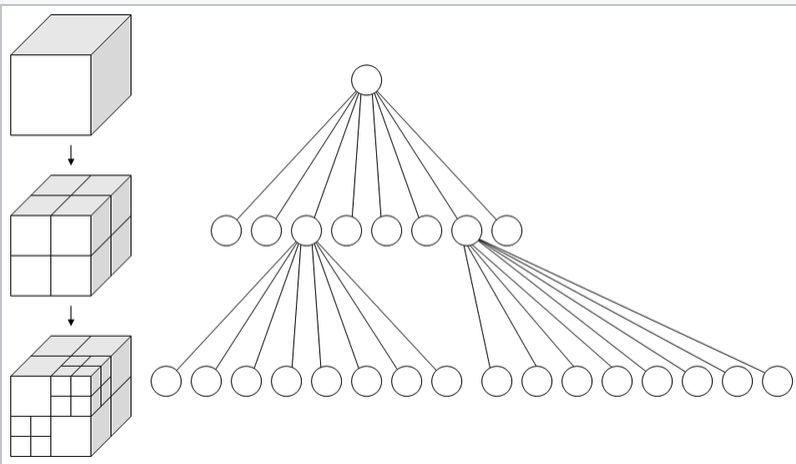

open3d 具有幾何類體類型的八元樹，可用於創建、搜尋、遍歷
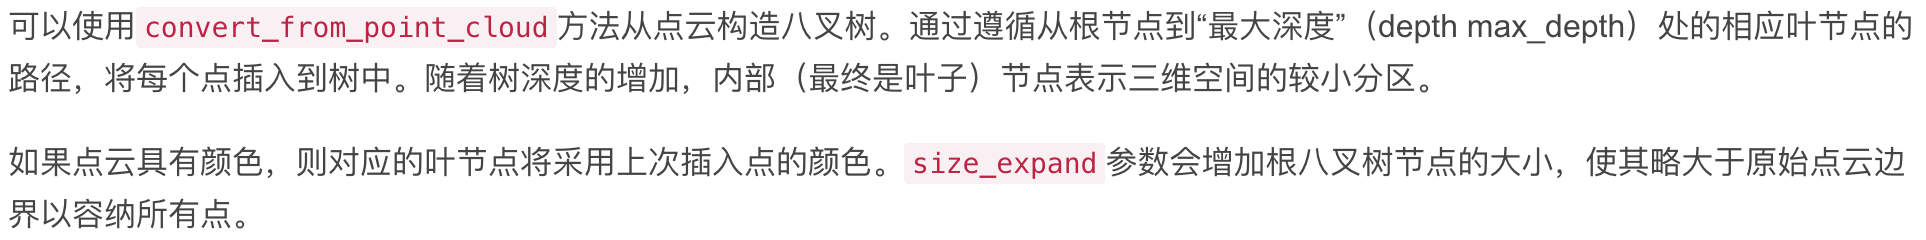

In [ ]:
import open3d as o3d
import numpy as np

# --------------------------- 載入點雲 ---------------------------
print("-> 正在載入點雲...")
pcd = o3d.io.read_point_cloud("bunnyData.pts")
print("原始點雲：", pcd)
# ==============================================================

# ------------------------- 建構 Octree --------------------------
print("Octree 分割")
octree = o3d.geometry.Octree(max_depth=4)
octree.convert_from_point_cloud(pcd, size_expand=0.01)
print("-> 正在可視化 Octree...")
o3d.visualization.draw_geometries([octree])
# ==============================================================


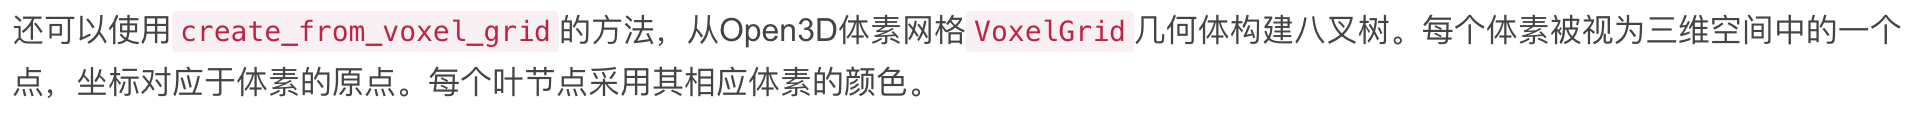

In [ ]:
import open3d as o3d
import numpy as np

# --------------------------- 載入點雲 ---------------------------
print("-> 正在載入點雲...")
pcd = o3d.io.read_point_cloud("bunnyData.pts")
print("原始點雲：", pcd)
# ==============================================================

# ------------------------- 建構 Octree --------------------------
print("體素化")
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=0.001)
print("體素：", voxel_grid)
print("正在可視化體素...")
o3d.visualization.draw_geometries([voxel_grid])

print("Octree 分割")
octree = o3d.geometry.Octree(max_depth=32)
octree.create_from_voxel_grid(voxel_grid)
print("Octree：", octree)
print("正在可視化 Octree...")
o3d.visualization.draw_geometries([octree])
# ==============================================================

主要類別：  
o3d.geometry.Octree
o3d.geometry.OctreeNode
o3d.geometry.OctreeInternalNode
o3d.geometry.OctreeLeafNode

Octree 建構與基本功能表

| 函式 / 方法名稱 | 參數 | 回傳 | 說明 |
|----------------|--------|--------|------|
| Octree(max_depth) | max_depth: int | Octree | 建立一個空的 octree，指定最大深度 |
| convert_from_point_cloud(pcd, size_expand=0.01) | pcd: PointCloud<br>size_expand: float | None | 自動根據點雲建立 octree（最常用方法） |
| create_from_voxel_grid(VoxelGrid) | VoxelGrid: open3d.geometry.VoxelGrid | 輸入的體素網格 (VoxelGrid) 物件。每個體素將被視為點雲中的一個點，其座標為該體素的原點 |
| insert_point(point, color=None) | point: 3D vector<br>color: optional | None | 將單一點插入現有 octree 結構 |
| locate_leaf_node(point) | point: 3D vector | (success, node) | 尋找該點所屬的 leaf node |
| traverse(callback) | callback: function | None | 以 DFS 方式遍歷 tree（內部結構全探索） |
| to_voxel_grid() | 無 | VoxelGrid | 將 octree 轉為 voxel grid（可視覺化） |
| clear() | 無 | None | 清空樹內容 |

Octree Node 類別與方法

| 節點類型 | 說明 | 方法 / 屬性 |
|---------|------|--------------|
| OctreeNode | 基底類別 | 無（抽象基礎） |
| OctreeInternalNode | 有 8 個子節點的內部節點 | children: list[8] |
| OctreeLeafNode | 最底層節點（儲存資料） | color: RGB<br>index: voxel index 等 |

節點遍歷與操作

| 方法名稱 | 參數 | 回傳 | 說明 |
|----------|--------|--------|------|
| traverse(callback) | callback(node, depth) | None | 深度優先搜尋整棵樹 |
| locate_leaf_node(point) | point: 3D vector | (bool, node) | 找到該點所在的 leaf node |
| find_leaf_node(origin, size) | 空間查詢 | node | 根據空間位置查找 leaf 節點 |

與 Voxel / 可視化 相關的方法

| 方法 / 類別 | 說明 |
|-------------|------|
| to_voxel_grid() | 將 octree 轉成可視覺化的 VoxelGrid（最常用） |
| OctreeLeafNode.color | 若插入點含 RGB，會出現在 leaf node |
| OctreeInternalNode.children | 八個子樹節點，用來遞迴可視化 |

Octree vs. KDTree

| 特性 | KDTree | Octree |
|------|--------|---------|
| 分割方式 | k-d 分割（超平面） | 空間 8 等分 |
| 最適用 | 最近鄰搜尋 | 大範圍空間分割、voxel 化 |
| 深度 | 不固定 | 由 max_depth 決定 |
| 記憶體 | 較省 | 較多（8 分木） |
| 應用 | ICP、KNN | 空間加速、體素表示、rendering |


統計濾波
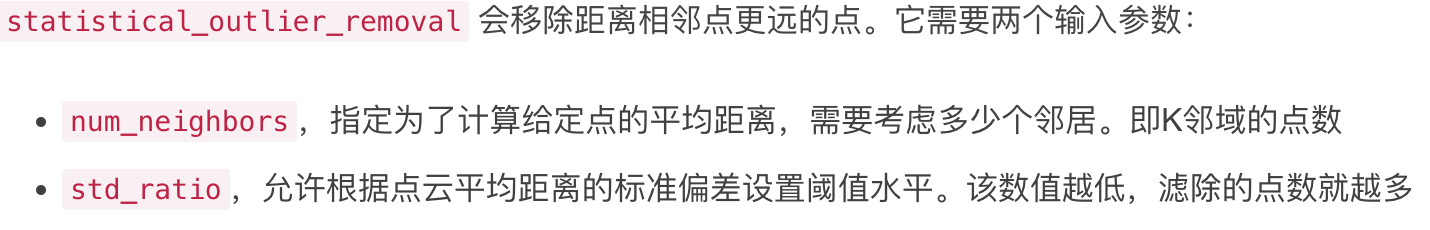

In [ ]:
import open3d as o3d
import numpy as np

print("-> 正在載入點雲...")
pcd = o3d.io.read_point_cloud("block.xyz")
print("原始點雲：", pcd)

# ------------------------- 統計濾波 --------------------------
print("-> 正在進行統計濾波...")
num_neighbors = 20  # K 鄰域點的個數
std_ratio = 1.0     # 標準差乘數

# 執行統計濾波，返回濾波後的點雲 sor_pcd 和對應的索引 ind
sor_pcd, ind = pcd.remove_statistical_outlier(num_neighbors, std_ratio)
sor_pcd.paint_uniform_color([0, 0, 1])
print("統計濾波後的點雲：", sor_pcd)

# 提取噪聲點雲
sor_noise_pcd = pcd.select_by_index(ind, invert=True)
print("噪聲點雲：", sor_noise_pcd)
sor_noise_pcd.paint_uniform_color([1, 0, 0])
# ===========================================================

# 可視化統計濾波後的點雲與噪聲點雲
o3d.visualization.draw_geometries([sor_pcd, sor_noise_pcd])

半徑濾波
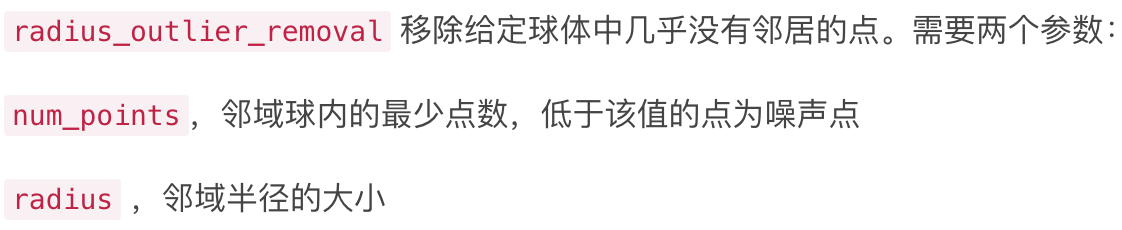

In [ ]:
import open3d as o3d
import numpy as np


print("-> 正在載入點雲...")
ply_point_cloud = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud(ply_point_cloud.path)
print("原始點雲：", pcd)

# ------------------------- 半徑濾波 --------------------------
print("-> 正在進行半徑濾波...")
num_points = 30  # 鄰域球內的最少點數，低於該值的點視為噪聲點
radius = 0.03    # 鄰域半徑大小

# 執行半徑濾波，返回濾波後的點雲 sor_pcd 和對應的索引 ind
sor_pcd, ind = pcd.remove_radius_outlier(num_points, radius)
sor_pcd.paint_uniform_color([0, 0, 1])
print("半徑濾波後的點雲：", sor_pcd)
sor_pcd.paint_uniform_color([0, 0, 1])

# 提取噪聲點雲
sor_noise_pcd = pcd.select_by_index(ind, invert=True)
print("噪聲點雲：", sor_noise_pcd)
sor_noise_pcd.paint_uniform_color([1, 0, 0])
# ===========================================================

# 可視化半徑濾波後的點雲和噪聲點雲
o3d.visualization.draw_geometries([sor_pcd, sor_noise_pcd])

Ball pivoting
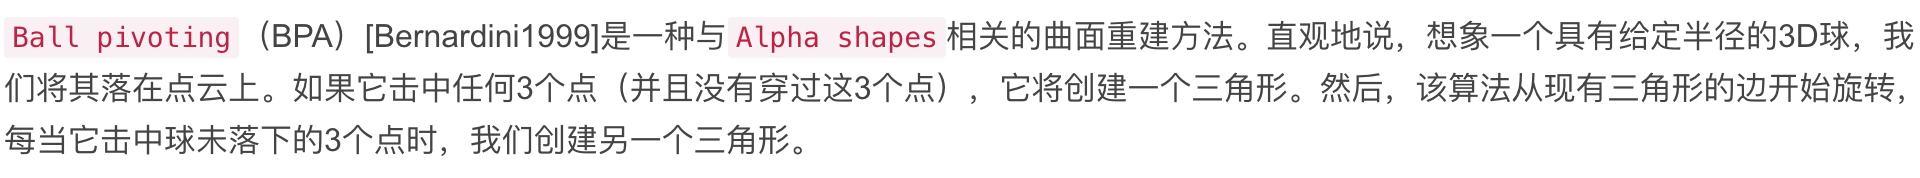

In Open 3D, the function is create_from_point_cloud_ball_pivoting

In [ ]:
import open3d as o3d
import numpy as np

# ---------------------- 定义点云体素化函数 ----------------------
def get_mesh(_relative_path):
    mesh = o3d.io.read_triangle_mesh(_relative_path)
    mesh.compute_vertex_normals()
    o3d.visualization.draw_geometries([mesh])
    return mesh
# =============================================================
#armadillo = o3d.data.ArmadilloMesh()
bunny_mesh = o3d.data.BunnyMesh()
#knot_mesh = o3d.data.KnotMesh()
# ------------------------- Ball pivoting --------------------------
print("->Ball pivoting...")
_relative_path = bunny_mesh.path    # 设置相对路径
N = 5000                        # 将点划分为N个体素
pcd = get_mesh(_relative_path).sample_points_poisson_disk(N)
o3d.visualization.draw_geometries([pcd])

radii = [0.005, 0.01, 0.02, 0.04]
rec_mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(pcd, o3d.utility.DoubleVector(radii))
o3d.visualization.draw_geometries([pcd, rec_mesh])
# ==============================================================

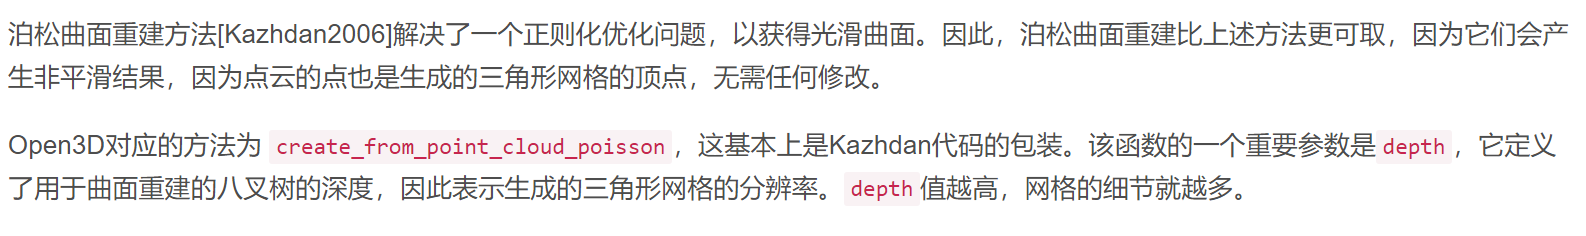

In [ ]:
import open3d as o3d
import numpy as np

# --------------------------- 載入點雲 ---------------------------
print("-> 正在載入點雲...")
pcd = o3d.io.read_point_cloud("bunnyData.pts")
print("原始點雲：", pcd)
# ==============================================================
o3d.visualization.draw_geometries([pcd])

# ------------------------- Poisson 重建 --------------------------
print("執行 Poisson 表面重建")
radius = 0.001   # 搜尋半徑
max_nn = 30      # 鄰域內用於估算法向量的最大點數
# pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius, max_nn))   # 執行法向量估計

o3d.visualization.draw_geometries([pcd], point_show_normal=True)

with o3d.utility.VerbosityContextManager(o3d.utility.VerbosityLevel.Debug) as cm:
    mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
        pcd,
        depth=16,
        scale=0.95
    )

print(mesh)
o3d.visualization.draw_geometries([mesh])
# ==============================================================

In [ ]:
import open3d as o3d
import numpy as np

# -------------------------- 定義點雲體素化函式 ---------------------------
def get_mesh(_relative_path):
    mesh = o3d.io.read_triangle_mesh(_relative_path)
    mesh.compute_vertex_normals()
    return mesh
# =====================================================================

# -------------------- Poisson surface reconstruction ------------------
# 載入點雲
print("-> Poisson surface reconstruction...")
bunny_mesh = o3d.data.BunnyMesh()
_relative_path = bunny_mesh.path    # 設定相對路徑
N = 6000                             # 將點雲採樣為 N 個點（Poisson disk sampling）
pcd = get_mesh(_relative_path).sample_points_poisson_disk(N)
pcd.normals = o3d.utility.Vector3dVector(np.zeros((1, 3)))  # 使現有法向量無效

# 法向量估計
pcd.estimate_normals()
o3d.visualization.draw_geometries([pcd], point_show_normal=True)

pcd.orient_normals_consistent_tangent_plane(100)
o3d.visualization.draw_geometries([pcd], point_show_normal=True)

# Poisson 重建
print("執行 Poisson 表面重建")
with o3d.utility.VerbosityContextManager(
        o3d.utility.VerbosityLevel.Debug) as cm:
    mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
        pcd, depth=9)

print(mesh)
o3d.visualization.draw_geometries([mesh])
# =====================================================================

Translate、Rotate、Scale、Transform
1. Translate
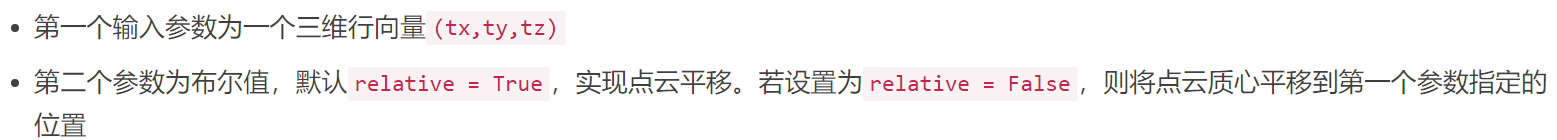

In [ ]:
import copy  # 點雲深拷貝
import open3d as o3d

# -------------------------- 載入點雲 ------------------------
print("-> 正在載入點雲...")
pcd = o3d.io.read_point_cloud("bunnyData.pts")
print(pcd)
print(f'pcd 質心：{pcd.get_center()}')
# ===========================================================

# -------------------------- 點雲平移 ------------------------
print("\n-> 沿 X 軸平移 0.2 m")
pcd_tx = copy.deepcopy(pcd).translate((0.2, 0, 0))
pcd_tx.paint_uniform_color([1, 0, 0])
print(pcd_tx)
print(f'pcd_tx 質心：{pcd_tx.get_center()}')

print("\n-> 沿 Y 軸平移 0.2 m")
pcd_ty = copy.deepcopy(pcd_tx).translate((0, 0.2, 0))
pcd_ty.paint_uniform_color([0, 1, 0])
print(pcd_ty)
print(f'pcd_ty 質心：{pcd_ty.get_center()}')

print("\n-> 沿 X 軸平移 -0.2 m，再沿 Y 軸平移 0.2 m")
pcd_txy = copy.deepcopy(pcd).translate((-0.2, 0.2, 0))
pcd_txy.paint_uniform_color([0, 0, 1])
print(pcd_txy)
print('pcd_txy 質心：', pcd_txy.get_center())
# ===========================================================

# -------------------------- 可視化 --------------------------
o3d.visualization.draw_geometries([pcd, pcd_tx, pcd_ty, pcd_txy])
# ===========================================================

In [ ]:
import copy  # 點雲深拷貝
import open3d as o3d

# -------------------------- 載入點雲 ------------------------
print("-> 正在載入點雲...")
pcd = o3d.io.read_point_cloud("bunnyData.pts")
print(pcd)
print(f'pcd 質心：{pcd.get_center()}')
# ===========================================================

# -------------------------- 點雲平移 ------------------------
print("\n-> 沿平移 (0.2, 0.2, 0.2)")
pcd_tx = copy.deepcopy(pcd).translate((0.2, 0.2, 0.2))
pcd_tx.paint_uniform_color([1, 0, 0])
print(pcd_tx)
print(f'pcd_tx 質心：{pcd_tx.get_center()}')

print("\n-> 將點雲質心平移到指定位置")
pcd_new = copy.deepcopy(pcd_tx).translate((0.2, 0.2, 0.2), relative=False)
# pcd_new = copy.deepcopy(pcd_tx).translate((0.2, 0.2, 0.2), False)  # relative 可以省略
pcd_new.paint_uniform_color([0, 1, 0])
print(pcd_new)
print(f'pcd_new 質心：{pcd_new.get_center()}')
# ===========================================================

# -------------------------- 可視化 --------------------------
o3d.visualization.draw_geometries([pcd, pcd_tx, pcd_new])
# ===========================================================

2. Rotate
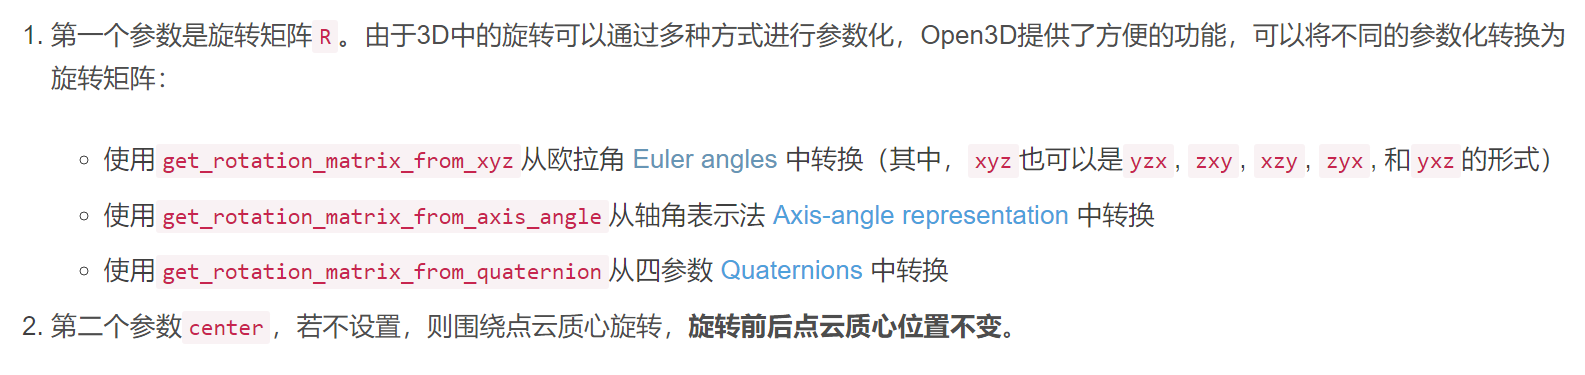
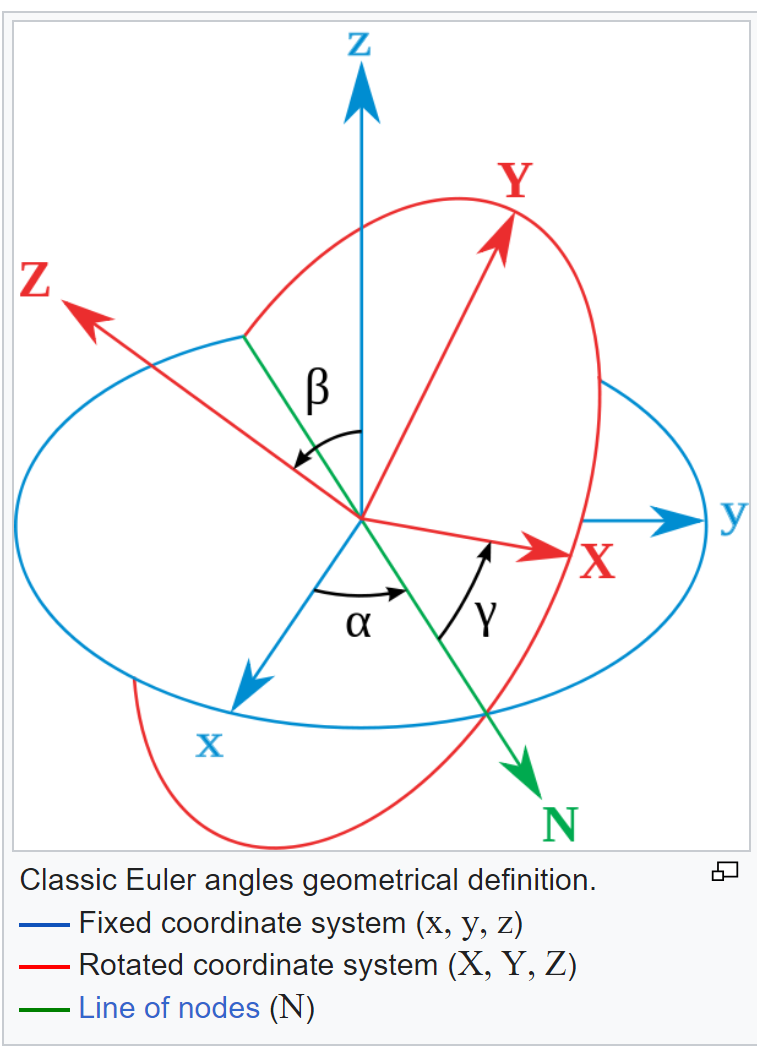
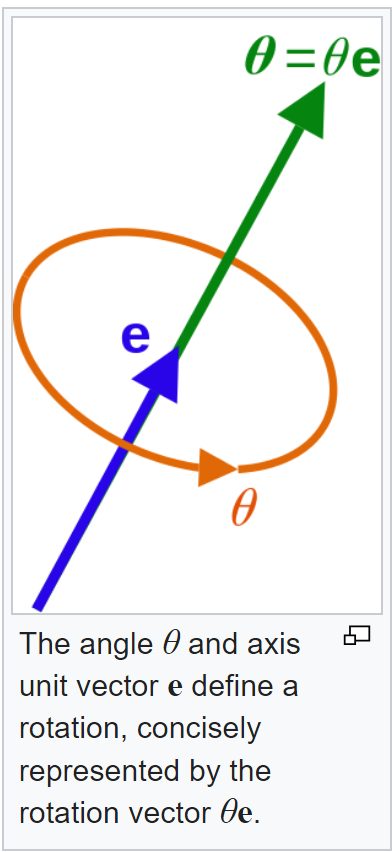
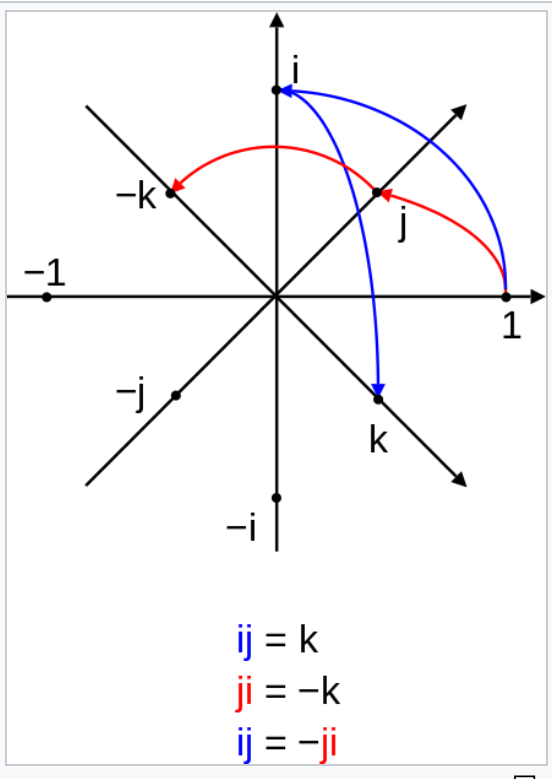
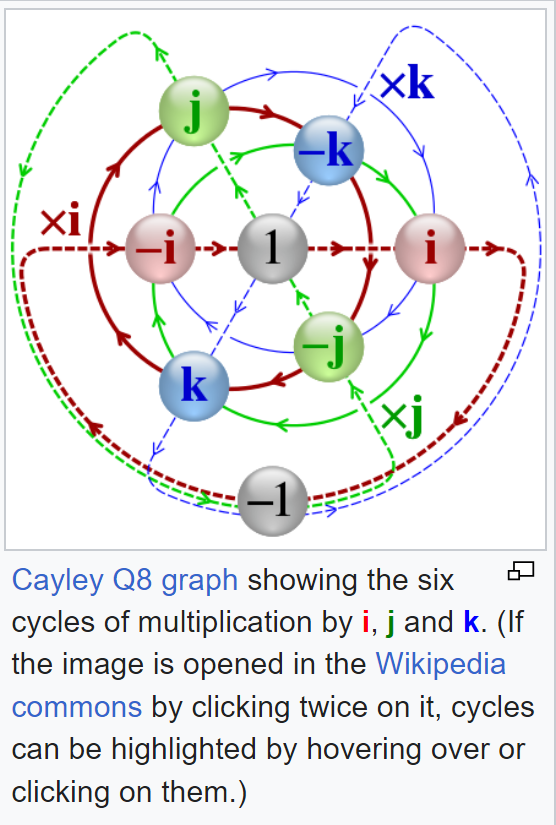
https://en.wikipedia.org/wiki/File:Cayley_Q8_quaternion_multiplication_graph.svg

In [ ]:
import copy  
import open3d as o3d
import numpy as np

# -------------------------- loading point cloud ------------------------
print("->loading point cloud... ")
pcd = o3d.io.read_point_cloud("bunnyData.pts")
print(pcd)
pcd.paint_uniform_color([1,0,0])
print("->pcd質心：",pcd.get_center())
# ===========================================================

# -------------------------- point cloud旋轉 ------------------------
print("\n->採用尤拉角进行point cloud旋轉")
pcd_EulerAngle = copy.deepcopy(pcd)
R1 = pcd.get_rotation_matrix_from_xyz((0,np.pi/2,0))
print("旋轉矩陣：\n",R1)
pcd_EulerAngle.rotate(R1)    # 不指定旋轉中心
pcd_EulerAngle.paint_uniform_color([0,0,1])
print("\n->pcd_EulerAngle質心：",pcd_EulerAngle.get_center())
# ===========================================================

# -------------------------- 可視化 --------------------------
o3d.visualization.draw_geometries([pcd, pcd_EulerAngle])
# ===========================================================


In [ ]:
import copy  
import open3d as o3d
import numpy as np

# -------------------------- loading point cloud ------------------------
print("->loading point cloud... ")
pcd = o3d.io.read_point_cloud("bunnyData.pts")
print(pcd)
pcd.paint_uniform_color([1,0,0])
print("->pcd質心：",pcd.get_center())
# ===========================================================

# -------------------------- point cloud旋轉 ------------------------
print("\n->採用尤拉角进行point cloud旋轉")
pcd_EulerAngle = copy.deepcopy(pcd)
R1 = pcd.get_rotation_matrix_from_xyz((0,np.pi/2,0))
print("旋轉矩陣：\n",R1)
pcd_EulerAngle.rotate(R1,center = (0.1,0.1,0.1))    # 指定旋轉中心
pcd_EulerAngle.paint_uniform_color([0,0,1])
print("\n->pcd_EulerAngle質心：",pcd_EulerAngle.get_center())
# ===========================================================

# -------------------------- 可視化 --------------------------
o3d.visualization.draw_geometries([pcd, pcd_EulerAngle])
# ===========================================================


3. Scale
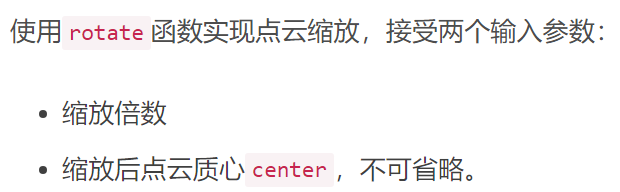

In [ ]:
import copy  
import open3d as o3d
import numpy as np

# -------------------------- loading point cloud ------------------------
print("->loading point cloud... ")
pcd = o3d.io.read_point_cloud("bunnyData.pts")
print(pcd)
pcd.paint_uniform_color([1,0,0])
print("->pcd質心：",pcd.get_center())
# ===========================================================

# -------------------------- 點雲縮放 ------------------------
print("\n->點雲縮放")
pcd_scale1 = copy.deepcopy(pcd)
pcd_scale1.scale(1.5,center=pcd.get_center())
pcd_scale1.paint_uniform_color([0,0,1])
print("->pcd_scale1質心：",pcd_scale1.get_center()) # 缩放前後質心不變

pcd_scale2 = copy.deepcopy(pcd)
pcd_scale2.scale(0.5,center=(1,1,1))	# 自定義縮放後的質心
pcd_scale2.paint_uniform_color([0,1,0])
print("->pcd_scale2質心：",pcd_scale2.get_center())
# ===========================================================

# -------------------------- 可視化 --------------------------
o3d.visualization.draw_geometries([pcd, pcd_scale1,pcd_scale2])
# ===========================================================


4. Transformation
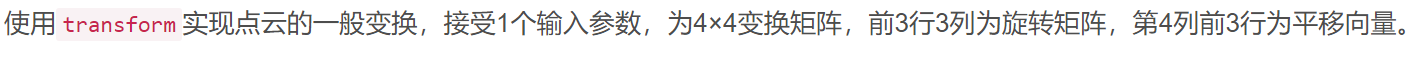

In [ ]:
import copy  
import open3d as o3d
import numpy as np

# -------------------------- loading point cloud ------------------------
print("->loading point cloud... ")
pcd = o3d.io.read_point_cloud("bunnyData.pts")
print(pcd)
pcd.paint_uniform_color([1,0,0])
print("->pcd質心：",pcd.get_center())
# ===========================================================

# -------------------------- transform ------------------------
print("\n->點雲變換")
pcd_T = copy.deepcopy(pcd)
T = np.eye(4)
T[ :3, :3] = pcd.get_rotation_matrix_from_xyz((np.pi/6,np.pi/4,0))	# 旋轉矩陣
T[0,3] = 1.0	# 平移向量的dx
T[1,3] = .5	# 平移向量的dy
print("\n->變換矩陣：\n",T)
pcd_T.transform(T)
pcd_T.paint_uniform_color([0,0,1])
print("\n->pcd_scale1質心：",pcd_T.get_center())
# ===========================================================

# -------------------------- 可視化 --------------------------
o3d.visualization.draw_geometries([pcd, pcd_T])
# ===========================================================


In [ ]:
import open3d as o3d
import numpy as np

# --------------------------- loading point cloud ---------------------------
print("->loading point cloud... ")
pcd = o3d.io.read_point_cloud("bunnyData.pts")
print("原始點雲：", pcd)
# ==============================================================

# --------------------------- voxelization -------------------------
print('voxelization')
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=0.001)
print("viewing...")
o3d.visualization.draw_geometries([voxel_grid])
# ==============================================================


In [ ]:
import open3d as o3d
import numpy as np


def get_mesh(_relative_path):
    mesh = o3d.io.read_triangle_mesh(_relative_path)
    mesh.compute_vertex_normals()
    return mesh


# ------------------------- voxlization --------------------------
print("->voxlization...")
bunny_mesh = o3d.data.BunnyMesh()
_relative_path = bunny_mesh.path    
N = 2000        # number of points to sample from mesh
pcd = get_mesh(_relative_path).sample_points_poisson_disk(N)

# fit to unit cube
pcd.scale(1 / np.max(pcd.get_max_bound() - pcd.get_min_bound()),
          center=pcd.get_center())
pcd.colors = o3d.utility.Vector3dVector(np.random.uniform(0, 1, size=(N, 3)))
print("voxelized point cloud downsampling：", pcd)
print("viewing...")
o3d.visualization.draw_geometries([pcd])

print('voxelization')
voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=0.05)
print("viewing...")
o3d.visualization.draw_geometries([voxel_grid])
# ===========================================================


In [ ]:
import open3d as o3d
import numpy as np

mesh = o3d.io.read_point_cloud('office.ply')
mesh.paint_uniform_color([0,0,1])
o3d.visualization.draw_geometries([mesh])